In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)

# Cargar el dataset desde data/raw/
df = pd.read_csv('../data/raw/Personal_Finance_Dataset.csv')

# Inspección inicial
print(f"Dimensiones del dataset: {df.shape}")
print("\n--- Información de tipos y nulos ---")
print(df.info())

print("\n--- Primeras filas ---")
df.head()

Dimensiones del dataset: (1500, 5)

--- Información de tipos y nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1500 non-null   object 
 1   Transaction Description  1500 non-null   object 
 2   Category                 1500 non-null   object 
 3   Amount                   1500 non-null   float64
 4   Type                     1500 non-null   object 
dtypes: float64(1), object(4)
memory usage: 58.7+ KB
None

--- Primeras filas ---


,Date,Transaction Description,Category,Amount,Type
0,2020-01-02,Score each.,Food & Drink,1485.69,Expense
1,2020-01-02,Quality throughout.,Utilities,1475.58,Expense
2,2020-01-04,Instead ahead despite measure ago.,Rent,1185.08,Expense
3,2020-01-05,Information last everything thank serve.,Investment,2291.00,Income
4,2020-01-13,Future choice whatever from.,Food & Drink,1126.88,Expense


In [3]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset desde su ubicación
df = pd.read_csv('../data/raw/Personal_Finance_Dataset.csv')

# 2. Renombrar columnas al formato requerido
df = df.rename(columns={
    'Amount': 'monto',
    'Date': 'fecha',
    'Category': 'categoria'
})

# Convertir la columna fecha a datetime
df['fecha'] = pd.to_datetime(df['fecha'])

# 3. Generar la columna 'frecuencia_ahorro'
def calcular_frecuencia_ahorro(monto):
    if monto < 500:
        return 'Baja'
    elif monto <= 2000:
        return 'Media'
    else:
        return 'Alta'

df['frecuencia_ahorro'] = df['monto'].apply(calcular_frecuencia_ahorro)

# 4. Validación de la tarea
columnas_requeridas = ['monto', 'fecha', 'categoria', 'frecuencia_ahorro']
columnas_presentes = all(col in df.columns for col in columnas_requeridas)

print("--- VERIFICACIÓN DE COLUMNAS REQUERIDAS ---")
print(f"¿Están todas las columnas requeridas presentes?: {columnas_presentes}")
print(f"Columnas en el DataFrame: {list(df.columns)}\n")

print("--- MUESTRA DEL DATASET PROCESADO ---")
print(df[['fecha', 'categoria', 'monto', 'frecuencia_ahorro']].head())

# Validación estricta de valores permitidos en frecuencia_ahorro
valores_permitidos = {'Baja', 'Media', 'Alta'}
valores_encontrados = set(df['frecuencia_ahorro'].unique())

es_valido = valores_encontrados.issubset(valores_permitidos)

print("--- VALIDACIÓN DE VALORES EN FRECUENCIA_AHORRO ---")
print(f"Valores únicos en la columna: {valores_encontrados}")
print(f"¿Los valores corresponden únicamente a Baja | Media | Alta?: {es_valido}")

# Conteo por categoría de ahorro
print("\n--- Conteo de registros por Frecuencia de Ahorro ---")
print(df['frecuencia_ahorro'].value_counts())

--- VERIFICACIÓN DE COLUMNAS REQUERIDAS ---
¿Están todas las columnas requeridas presentes?: True
Columnas en el DataFrame: ['fecha', 'Transaction Description', 'categoria', 'monto', 'Type', 'frecuencia_ahorro']

--- MUESTRA DEL DATASET PROCESADO ---
       fecha     categoria    monto frecuencia_ahorro
0 2020-01-02  Food & Drink  1485.69             Media
1 2020-01-02     Utilities  1475.58             Media
2 2020-01-04          Rent  1185.08             Media
3 2020-01-05    Investment  2291.00              Alta
4 2020-01-13  Food & Drink  1126.88             Media
--- VALIDACIÓN DE VALORES EN FRECUENCIA_AHORRO ---
Valores únicos en la columna: {'Alta', 'Media', 'Baja'}
¿Los valores corresponden únicamente a Baja | Media | Alta?: True

--- Conteo de registros por Frecuencia de Ahorro ---
frecuencia_ahorro
Media    1022
Baja      297
Alta      181
Name: count, dtype: int64


--- ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES NUMÉRICAS ---
        count         mean         std    min     25%       50%        75%  \
monto  1500.0  1307.520913  982.283361  14.37  629.34  1156.285  1712.9325   

          max  
monto  4996.0  

--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---
                  count unique      top  freq
categoria          1500     10     Rent   165
frecuencia_ahorro  1500      3    Media  1022
Type               1500      2  Expense  1222

--- ANÁLISIS DE OUTLIERS EN MONTO ---
Límite inferior para valores atípicos: -996.05
Límite superior para valores atípicos: 3338.32
Cantidad de outliers detectados: 88 (5.87%)


C:\Users\andre\AppData\Local\Temp\ipykernel_17104\209276127.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='frecuencia_ahorro', y='monto', order=['Baja', 'Media', 'Alta'], ax=axes[0], palette='Set2')


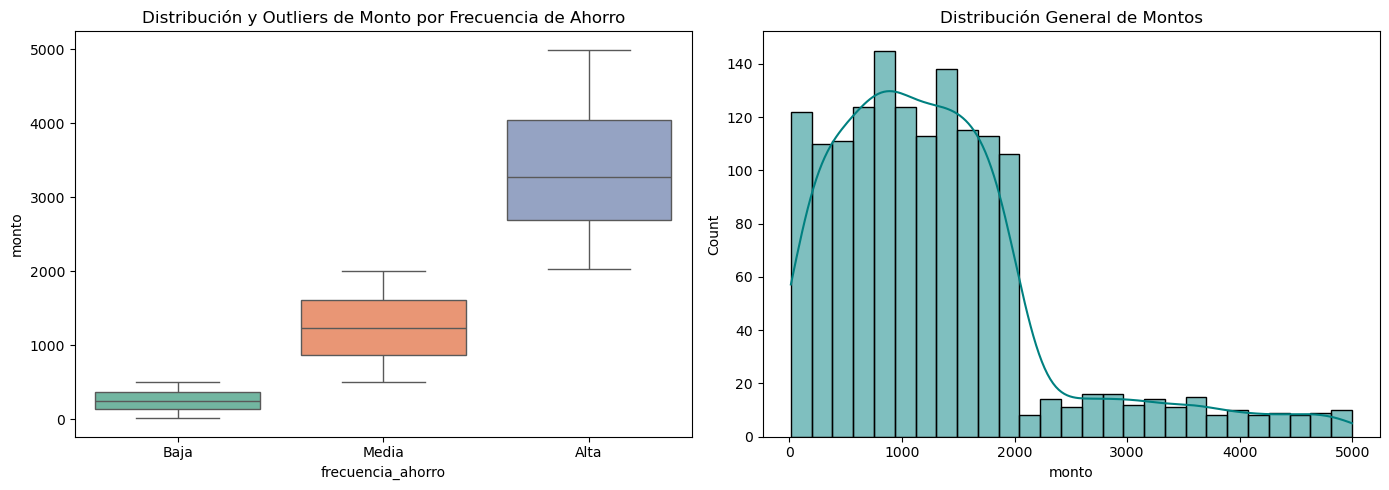

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Estadísticas descriptivas completas por columna
print("--- ESTADÍSTICAS DESCRIPTIVAS DE LAS VARIABLES NUMÉRICAS ---")
print(df[['monto']].describe().T)

print("\n--- DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS ---")
print(df[['categoria', 'frecuencia_ahorro', 'Type']].describe(include='object').T)

# 2. Detección de Outliers en la columna 'monto' mediante IQR (Rango Intercuartílico)
Q1 = df['monto'].quantile(0.25)
Q3 = df['monto'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['monto'] < limite_inferior) | (df['monto'] > limite_superior)]

print("\n--- ANÁLISIS DE OUTLIERS EN MONTO ---")
print(f"Límite inferior para valores atípicos: {limite_inferior:.2f}")
print(f"Límite superior para valores atípicos: {limite_superior:.2f}")
print(f"Cantidad de outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# 3. Visualización Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot para visualizar outliers en 'monto'
sns.boxplot(data=df, x='frecuencia_ahorro', y='monto', order=['Baja', 'Media', 'Alta'], ax=axes[0], palette='Set2')
axes[0].set_title('Distribución y Outliers de Monto por Frecuencia de Ahorro')

# Histograma de montos
sns.histplot(data=df, x='monto', kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribución General de Montos')

plt.tight_layout()
plt.show()